# 03 — K-means Clustering Recommender (Xizhi)
Unsupervised approach: cluster (user, song) joint feature vectors,
then recommend popular songs from the matched cluster.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..') / 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

from preprocess import load_and_clean, build_joint_features, build_user_features, build_song_features
from kmeans_recommender import KMeansRecommender, elbow_analysis, plot_elbow
from evaluate import kmeans_genre_accuracy

sns.set_theme(style='whitegrid')
df = load_and_clean()
joint = build_joint_features(df)
user_feats = build_user_features(df)
song_feats = build_song_features(df)
print('Data shape:', df.shape, '| Joint features:', joint.shape)

Data shape: (170, 12) | Joint features: (170, 34)


## Step 1: Scale features

In [2]:
scaler = StandardScaler()
scaled = scaler.fit_transform(joint.values)
print('Scaled matrix shape:', scaled.shape)

Scaled matrix shape: (170, 34)


## Step 2: Elbow method + Silhouette analysis to choose K

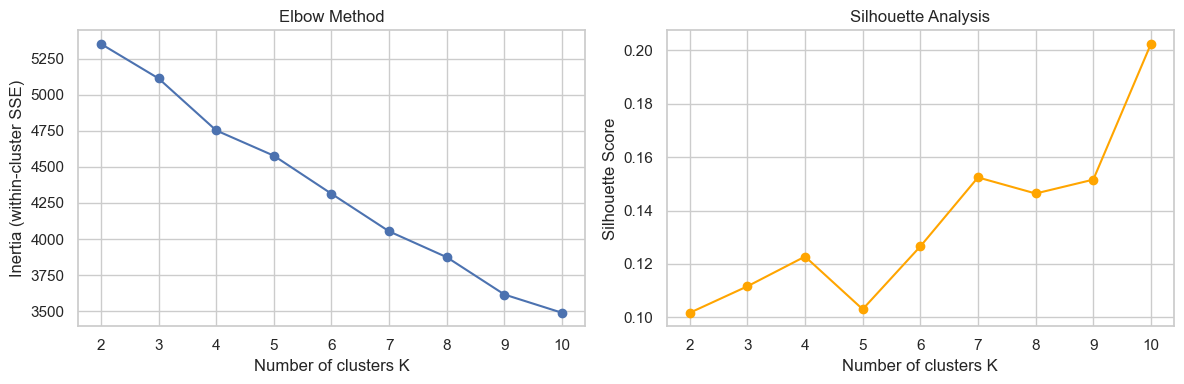

K  | Inertia   | Silhouette
 2 |   5354.21 | 0.1017
 3 |   5114.37 | 0.1116
 4 |   4753.56 | 0.1228
 5 |   4578.02 | 0.1031
 6 |   4313.77 | 0.1266
 7 |   4052.85 | 0.1524
 8 |   3873.52 | 0.1464
 9 |   3614.63 | 0.1516
10 |   3487.84 | 0.2023


In [3]:
k_range = range(2, 11)
inertias, sil_scores = elbow_analysis(scaled, k_range=k_range)

fig = plot_elbow(k_range, inertias, sil_scores)
plt.show()

print('K  | Inertia   | Silhouette')
for k, ine, sil in zip(k_range, inertias, sil_scores):
    print(f'{k:2d} | {ine:9.2f} | {sil:.4f}')

## Step 3: Fit final model with chosen K

In [4]:
# Choose K with highest silhouette score
best_k = list(k_range)[int(np.argmax(sil_scores))]
print(f'Chosen K = {best_k} (silhouette = {max(sil_scores):.4f})')

model = KMeansRecommender(n_clusters=best_k)
model.fit(df, joint)
print('Cluster distribution:')
print(df['user_id'].to_frame().assign(cluster=model._labels)['cluster'].value_counts().sort_index())

Chosen K = 10 (silhouette = 0.2023)
Cluster distribution:
cluster
0    22
1    59
2    17
3     1
4     7
5     2
6    44
7     2
8    10
9     6
Name: count, dtype: int64


## Step 4: Cluster genre profiles

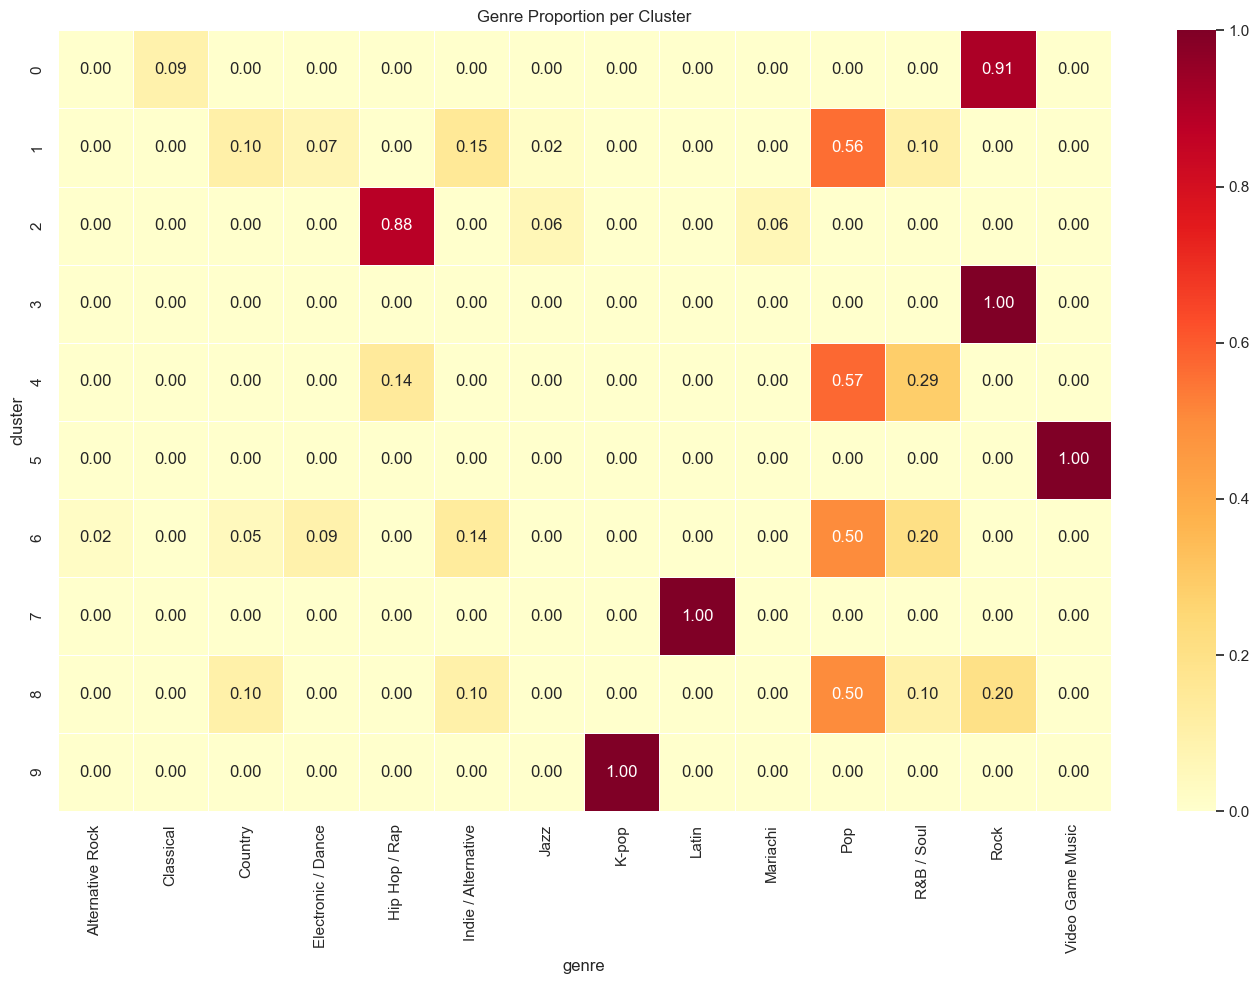

In [5]:
profile = model.cluster_genre_profile()

# Pivot for heatmap
pivot = profile.pivot_table(index='cluster', columns='genre', values='proportion', fill_value=0)
fig, ax = plt.subplots(figsize=(14, max(3, best_k)))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5, ax=ax)
ax.set_title('Genre Proportion per Cluster')
plt.tight_layout()
plt.show()

## Step 5: Demographic profile per cluster

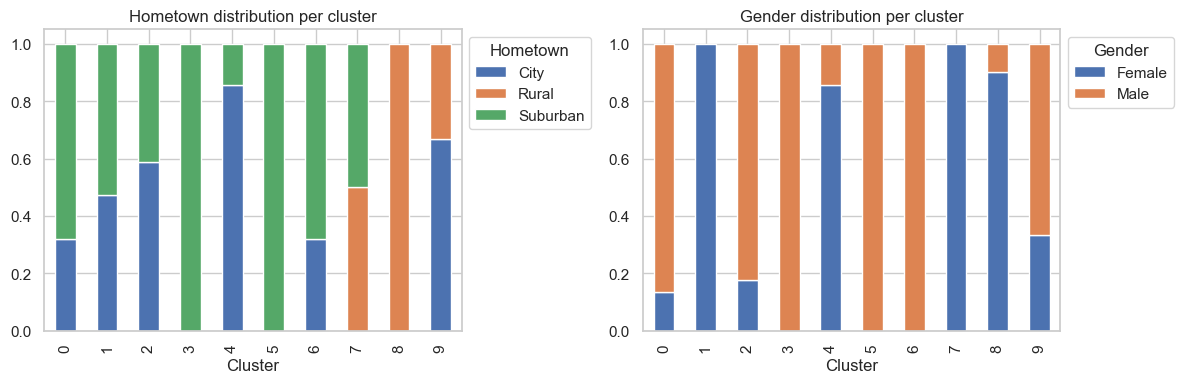

In [6]:
df_with_cluster = model._df.copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pd.crosstab(df_with_cluster['cluster'], df_with_cluster['hometown'], normalize='index').plot(
    kind='bar', ax=axes[0], stacked=True
)
axes[0].set_title('Hometown distribution per cluster')
axes[0].set_xlabel('Cluster')
axes[0].legend(title='Hometown', bbox_to_anchor=(1, 1))

pd.crosstab(df_with_cluster['cluster'], df_with_cluster['gender'], normalize='index').plot(
    kind='bar', ax=axes[1], stacked=True
)
axes[1].set_title('Gender distribution per cluster')
axes[1].set_xlabel('Cluster')
axes[1].legend(title='Gender', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

## Step 6: Sample recommendations

In [7]:
# Pick the first user and get recommendations
sample_user = df['user_id'].value_counts().index[0]
user_row_idx = df[df['user_id'] == sample_user].index[0]

demo_vec = user_feats.iloc[user_row_idx].values
song_vec = np.zeros(song_feats.shape[1])
exclude = df[df['user_id'] == sample_user]['song'].tolist()

print(f"User: {sample_user}")
print("Known songs:")
print(df[df['user_id'] == sample_user][['song', 'genre']].to_string(index=False))
print("\nK-means recommendations:")
print(model.recommend(demo_vec, song_vec, exclude_songs=exclude, top_k=5))

User: mariokart
Known songs:
                song      genre
           TITFORTAT        Pop
  Birds of a Feather        Pop
         The Subway         Pop
   BAILE INoLVIDABLE      Latin
Rolling in the Deep  R&B / Soul
         Getaway Car       Rock
   Sign of the Times       Rock
           Hurricane        Pop
            Takedown      K-pop
        Meant to be     Country

K-means recommendations:
                         song        artist                genre  count
0                       Paris  Chainsmokers                  Pop      1
1  Reality TV Argument Bleeds     Wednesday  Indie / Alternative      1


## Step 7: Genre accuracy evaluation

In [8]:
results = kmeans_genre_accuracy(
    df,
    recommend_fn=model.recommend,
    user_features=user_feats,
    song_features=song_feats,
    top_k=1,
)
print('K-means evaluation results:')
print(results)

K-means evaluation results:
{'genre_accuracy': 0.1529, 'n_rows': 170}
